# Executive Summary

## Decisions to be impacted
The goal of this project is to predict and highlight crime hotspots to assist law enforcement in better resource allocation and proactive crime prevention. Accurate crime prediction allows for optimized patrol routing, quicker response to high-risk areas, and informed decision-making in crime prevention initiatives.

## Business Value
By predicting hotspots, this project provides value to both law enforcement and the community. Benefits include:

- Reduced crime rates through proactive policing
- Increased efficiency for allocation of public funds
- Enhanced public safety and confidence


## Data Assets

- NIBRS data: Crime incidents with spatial-temporal information from 2021 to January 2025
- Supplementary datasets: Neighborhood population census data and city/neighborhood boundary shapefiles

# Data Pre-Processing

### Define Data Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
data_path = '/content/drive/MyDrive/data/cleaned_2021-jan2025.csv'
city_bounds_path ='/content/stl_boundary.shp'

Mounted at /content/drive/


In [ ]:
!wget 'https://www.stlouis-mo.gov/data/upload/data-files/stl_boundary.zip'
!unzip '/content/stl_boundary.zip'
!rm "/content/stl_boundary.zip"
city_bounds_path ='/content/drive/MyDrive/data/city_bounds/stl_boundary.shp'

--2025-04-30 23:26:50--  https://www.stlouis-mo.gov/data/upload/data-files/stl_boundary.zip
Resolving www.stlouis-mo.gov (www.stlouis-mo.gov)... 205.235.232.15
Connecting to www.stlouis-mo.gov (www.stlouis-mo.gov)|205.235.232.15|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5251 (5.1K) [application/x-zip-compressed]
Saving to: ‘stl_boundary.zip’

stl_boundary.zip    100%[===================>]   5.13K  --.-KB/s    in 0s      

2025-04-30 23:26:50 (1.67 GB/s) - ‘stl_boundary.zip’ saved [5251/5251]

Archive:  /content/stl_boundary.zip
  inflating: stl_boundary.sbn        
  inflating: stl_boundary.sbx        
  inflating: stl_boundary.shp        
  inflating: stl_boundary.shp.xml    
  inflating: stl_boundary.shx        
  inflating: stl_boundary.dbf        
  inflating: stl_boundary.prj        


In [ ]:
!wget 'https://static.stlouis-mo.gov/open-data/planning/neighborhoods/neighborhoods.zip'
!unzip '/content/neighborhoods.zip'
!rm "/content/neighborhoods.zip"
neighborhoods_path = '/content/drive/MyDrive/data/Neighborhoods/Neighborhoods.shp'

--2025-04-30 23:26:51--  https://static.stlouis-mo.gov/open-data/planning/neighborhoods/neighborhoods.zip
Resolving static.stlouis-mo.gov (static.stlouis-mo.gov)... 205.235.232.31
Connecting to static.stlouis-mo.gov (static.stlouis-mo.gov)|205.235.232.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 223184 (218K) [application/x-zip-compressed]
Saving to: ‘neighborhoods.zip’

neighborhoods.zip   100%[===================>] 217.95K  1.04MB/s    in 0.2s    

2025-04-30 23:26:51 (1.04 MB/s) - ‘neighborhoods.zip’ saved [223184/223184]

Archive:  /content/neighborhoods.zip
 extracting: Neighborhoods/Neighborhoods.cpg  
  inflating: Neighborhoods/Neighborhoods.dbf  
  inflating: Neighborhoods/Neighborhoods.prj  
  inflating: Neighborhoods/Neighborhoods.sbn  
  inflating: Neighborhoods/Neighborhoods.sbx  
  inflating: Neighborhoods/Neighborhoods.shp  
  inflating: Neighborhoods/Neighborhoods.shp.xml  
  inflating: Neighborhoods/Neighborhoods.shx  


### Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import geopandas as gpd
from shapely.geometry import Point
# from esda.moran import Moran_Local # Removed as not used by ST-ACLCrime
# from libpysal.weights import Queen # Removed as not used by ST-ACLCrime
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm.notebook import tqdm # For progress bars
import warnings

# --- PyTorch Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore', category=UserWarning, module='geopandas*')
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)
# warnings.filterwarnings('ignore', category=pd.core.common.SettingWithCopyWarning)

print(f"PyTorch Version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch Version: 2.6.0+cu124
Using device: cuda


### Crime Category Function & Constants

In [ ]:
# Using the provided NIBRS categorization
NIBRS_CATEGORIES = {
    'ASSAULT': ['13A', '13B', '13C'],
    'THEFT': ['23A', '23B', '23C', '23D', '23E', '23F', '23G', '23H', '240'], # Added 240 based on sample data Offense
    'SEX CRIMES': ['36A', '36B', '11A', '11B', '11C', '11D'],
    'HOMICIDE': ['09A', '09B', '09C'],
    'GROUP B': ['90A', '90F','90B','90C','90D','90E','90H','90H','90I','90J','90Z'],
    'FRAUD': ['26A', '26B', '26C', '26D', '26E'],
    'DRUG OFFENSES': ['35A', '35B'],
    'BURGLARY': ['220']
}

    # Function to map NIBRS code to category
def map_to_category(nibrs_code):
    """
    Map NIBRS code to simplified crime types.
    """
    # Convert to string and strip whitespace for consistent comparison
    nibrs_code = str(nibrs_code).strip()

    if nibrs_code in NIBRS_CATEGORIES['ASSAULT'] or nibrs_code in NIBRS_CATEGORIES['HOMICIDE']:
        return "VIOLENT CRIME"
    elif nibrs_code in NIBRS_CATEGORIES['SEX CRIMES']:
        return "SEX CRIMES"
    elif nibrs_code in NIBRS_CATEGORIES['THEFT'] or nibrs_code in NIBRS_CATEGORIES['BURGLARY'] or nibrs_code in NIBRS_CATEGORIES['FRAUD']:
        return "THEFT" # Grouping Burglary/Fraud under Theft for this model, adjust if needed
    elif nibrs_code in NIBRS_CATEGORIES['DRUG OFFENSES']:
        return "DRUG OFFENSES"
    else: # Includes Group B and any unmapped codes
        return 'OTHER'

### Preprocessing Function Definition

In [ ]:
# Using the provided preprocessing function, slightly modified for clarity
def preprocess_crime_data(file_path, city_bounds_path):
    """
    Preprocesses crime data: loads, filters by bounds, normalizes time/space,
    categorizes crime types, and handles missing essential data.
    """
    print(f"Loading data from {file_path}...")
    df = pd.read_csv(file_path)
    print(f"Original data shape: {df.shape}")

    processed_df = df.copy()

    # 1. Filter by City Bounds
    print("\nFiltering points by city bounds...")
    try:
        city_bounds = gpd.read_file(city_bounds_path)
        # Drop rows with missing coordinates before creating GeoDataFrame
        processed_df.dropna(subset=['Latitude', 'Longitude'], inplace=True)
        points = gpd.GeoDataFrame(processed_df, geometry=gpd.points_from_xy(processed_df.Longitude, processed_df.Latitude))
        points.set_crs(epsg=4326, inplace=True)

        if city_bounds.crs != points.crs:
            points = points.to_crs(city_bounds.crs)

        within_points = gpd.sjoin(points, city_bounds, how='inner', predicate='within')
        # Drop columns added by sjoin and original geometry
        columns_to_drop = ['index_right'] + list(city_bounds.columns)
        processed_df = pd.DataFrame(within_points.drop(columns=columns_to_drop))
        print(f"Data shape after filtering by city bounds: {processed_df.shape}")
    except Exception as e:
        print(f"Error during spatial filtering: {e}. Skipping bound filtering.")
        processed_df.dropna(subset=['Latitude', 'Longitude'], inplace=True) # Still drop missing coords

    # 2. Handle Time Data
    print("\nProcessing time data...")
    processed_df['IncidentDate'] = pd.to_datetime(processed_df['IncidentDate'], errors='coerce')
    processed_df.dropna(subset=['IncidentDate'], inplace=True) # Drop rows where date conversion failed

    def time_to_fraction(time_str):
        try:
            if pd.isna(time_str): return np.nan
            time_str = str(time_str).split('.')[0] # Handle potential float issues
            if ':' in time_str:
                parts = time_str.split(':')
                h, m = int(parts[0]), int(parts[1])
                s = int(parts[2]) if len(parts) == 3 else 0
            else:
                time_int = int(time_str)
                h = time_int // 100
                m = time_int % 100
                s = 0
            if not (0 <= h <= 23 and 0 <= m <= 59 and 0 <= s <= 59): return np.nan # Validate time parts
            return (h * 3600 + m * 60 + s) / (24 * 3600)
        except: return np.nan

    processed_df['time_fraction'] = processed_df['OccurredFromTime'].apply(time_to_fraction)

    # 3. Filter Missing Essential Data & Specific Addresses
    print("\nFiltering missing essential data and specific locations...")
    address_filter = ['200 S TUCKER BLVD', '1915 OLIVE ST', '1915 OLIVE'] # Addresses to exclude
    initial_rows = len(processed_df)

    # Filter date range (Jan 1, 2021 onwards)
    processed_df = processed_df[processed_df['IncidentDate'] >= '2021-01-01']
    print(f"Removed {initial_rows - len(processed_df)} rows with dates before 2021-01-01.")
    initial_rows = len(processed_df)

    # Filter specific incident locations
    processed_df = processed_df[~processed_df['IncidentLocation'].astype(str).isin(address_filter)]
    print(f"Removed {initial_rows - len(processed_df)} rows with specified addresses.")
    initial_rows = len(processed_df)

    # Drop rows where essential time data is missing
    processed_df.dropna(subset=['time_fraction'], inplace=True)
    print(f"Removed {initial_rows - len(processed_df)} rows with missing time fraction.")

    print(f"Data shape after initial filtering: {processed_df.shape}")
    if processed_df.empty:
        print("DataFrame is empty after initial filtering. Cannot proceed.")
        return pd.DataFrame() # Return empty DataFrame

    # 4. Crime Type Categorization
    print("\nCategorizing crime types...")
    processed_df['crime_category'] = processed_df['NIBRS'].apply(map_to_category)
    print("\nCrime category distribution:")
    print(processed_df['crime_category'].value_counts())

    # 5. Select Final Columns (Removed normalization for now, will normalize grids later)
    final_cols = ['IncidentDate', 'time_fraction', 'Latitude', 'Longitude',
                  'crime_category', 'NIBRS', 'IncidentNum', 'FirearmUsed',
                  'Offense', 'IncidentLocation']
    # Ensure all final columns exist, add missing ones with NaN if necessary
    for col in final_cols:
        if col not in processed_df.columns:
            processed_df[col] = np.nan
    final_df = processed_df[final_cols].copy()

    # Sort by date for chronological processing
    final_df.sort_values(by='IncidentDate', inplace=True)
    final_df.reset_index(drop=True, inplace=True)

    print(f"\nFinal processed data shape: {final_df.shape}")
    return final_df

### Execute Preprocessing

In [ ]:
processed_data_full = preprocess_crime_data(data_path, city_bounds_path)

if not processed_data_full.empty:
    # Filter for Theft Crimes (as per paper's focus)
    theft_data = processed_data_full[processed_data_full['crime_category'] == 'THEFT'].copy()
    print(f"\nFiltered data shape (Theft only): {theft_data.shape}")
    if theft_data.empty:
        print("No theft data found after filtering.")
    else:
        print("\nSample of processed theft data:")
        print(theft_data.head())
        # Get date range for theft data
        min_date = theft_data['IncidentDate'].min()
        max_date = theft_data['IncidentDate'].max()
        print(f"\nTheft data date range: {min_date.date()} to {max_date.date()}")
else:
    print("Preprocessing resulted in an empty DataFrame.")
    theft_data = pd.DataFrame() # Ensure theft_data exists as an empty DF

Loading data from /content/drive/MyDrive/data/cleaned_2021-jan2025.csv...
Original data shape: (228776, 22)

Filtering points by city bounds...
Data shape after filtering by city bounds: (223931, 22)

Processing time data...

Filtering missing essential data and specific locations...
Removed 933 rows with dates before 2021-01-01.
Removed 609 rows with specified addresses.
Removed 0 rows with missing time fraction.
Data shape after initial filtering: (217559, 23)

Categorizing crime types...

Crime category distribution:
crime_category
OTHER            105340
THEFT             78934
VIOLENT CRIME     24371
DRUG OFFENSES      7875
SEX CRIMES         1039
Name: count, dtype: int64

Final processed data shape: (217559, 10)

Filtered data shape (Theft only): (78934, 10)

Sample of processed theft data:
  IncidentDate  time_fraction   Latitude  Longitude crime_category NIBRS  \
3   2021-01-01       0.635417  38.670919 -90.204200          THEFT   220   
6   2021-01-01       0.416667  38.66458

# Grid Generation & Sequence Creation

### Define Grid Parameters and Generate Daily Grids

Grid Dimensions: H=47, W=28

Generating daily grids from 2021-01-01 to 2024-12-31...


  0%|          | 0/1461 [00:00<?, ?it/s]

Generated 1461 daily grids.
Shape of daily_grids array: (1461, 47, 28)
\nOriginal max grid value: 11.00
Transformed max grid value: 2.48


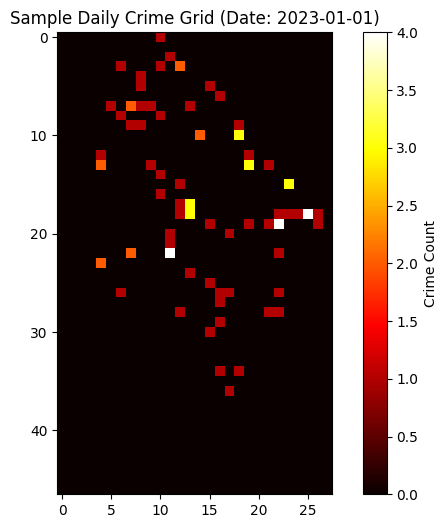

In [ ]:
# --- Grid Parameters ---
# Adjust bin_size to control grid resolution. Paper used 2000m and 1000m.
# Converting meters to degrees is approximate and location-dependent.
# Let's start with a degree-based bin size similar to the original notebook.
# Experiment with this value. Smaller value = finer grid, more cells.

bin_size_deg = 0.005 # Approximate ~300m in mid-latitudes

daily_grids = []
grid_dates = []
GRID_H, GRID_W = 0, 0 # Initialize grid dimensions

if not theft_data.empty:
    lat_min, lat_max = theft_data['Latitude'].min(), theft_data['Latitude'].max()
    lon_min, lon_max = theft_data['Longitude'].min(), theft_data['Longitude'].max()

    # Define bins based on overall data range and bin size
    lat_bins = np.arange(lat_min, lat_max, bin_size_deg)
    lon_bins = np.arange(lon_min, lon_max, bin_size_deg)
    GRID_H = len(lat_bins) - 1
    GRID_W = len(lon_bins) - 1
    print(f"Grid Dimensions: H={GRID_H}, W={GRID_W}")

    # Generate all dates in the range
    all_dates = pd.date_range(start=min_date, end=max_date, freq='D')
    grid_dates = list(all_dates)

    # Group data by date for efficient histogram generation
    grouped_data = theft_data.groupby(theft_data['IncidentDate'].dt.date)

    print(f"\nGenerating daily grids from {min_date.date()} to {max_date.date()}...")
    for date in tqdm(all_dates.date):
        if date in grouped_data.groups:
            date_data = grouped_data.get_group(date)
            # Create 2D histogram (crime count grid)
            grid, _, _ = np.histogram2d(date_data['Latitude'], date_data['Longitude'], bins=[lat_bins, lon_bins])
            daily_grids.append(grid)
        else:
            # Append an empty grid if no crime occurred on that day
            daily_grids.append(np.zeros((GRID_H, GRID_W)))

    daily_grids = np.array(daily_grids)
    print(f"Generated {len(daily_grids)} daily grids.")
    print(f"Shape of daily_grids array: {daily_grids.shape}")

    # --- Add this section for Log Transformation ---
    print(f"\\nOriginal max grid value: {daily_grids.max():.2f}")
    # Apply log(1+x) transformation to handle zeros and compress range
    daily_grids_transformed = np.log1p(daily_grids)
    print(f"Transformed max grid value: {daily_grids_transformed.max():.2f}")
    # --- Use daily_grids_transformed below ---

    # Optional: Visualize a sample grid
    if len(daily_grids) > 0:
        plt.figure(figsize=(8, 6))
        plt.imshow(daily_grids[len(daily_grids)//2], cmap='hot', interpolation='nearest') # Show a middle grid
        plt.title(f'Sample Daily Crime Grid (Date: {grid_dates[len(daily_grids)//2].date()})')
        plt.colorbar(label='Crime Count')
        plt.show()
else:
    print("Theft data is empty, cannot generate grids.")

### Create Input Sequences (Closeness, Period) and Targets

In [ ]:
def create_sequences(grids, dates, lc=3, ld=4, p=7):
    """
    Creates closeness, period, and target sequences from daily grids.
    Args:
        grids (np.array): Array of daily grids (num_days, height, width).
        dates (list): List of corresponding datetime objects for the grids.
        lc (int): Length of the closeness sequence.
        ld (int): Length of the period sequence.
        p (int): Periodicity (e.g., 7 for weekly).
    Returns:
        tuple: (Xc_all, Xd_all, Y_all, T_all) numpy arrays and target dates list.
    """
    Xc_all, Xd_all, Y_all, T_all = [], [], [], []
    min_required_hist = max(lc, ld * p) # Minimum days of history needed

    print(f"Creating sequences with lc={lc}, ld={ld}, p={p}...")
    print(f"Minimum required history: {min_required_hist} days")

    if len(grids) <= min_required_hist:
        print("Not enough data to create sequences.")
        return np.array([]), np.array([]), np.array([]), []

    # Iterate from the first day we have enough history to the end
    for t in tqdm(range(min_required_hist, len(grids))):
        # Target (grid for day t)
        Y = grids[t]

        # Closeness sequence (days t-lc to t-1)
        Xc = grids[t-lc : t]

        # Period sequence (days t-ld*p, t-(ld-1)*p, ..., t-1*p)
        Xd_indices = [t - i * p for i in range(ld, 0, -1)] # Indices for periodic days
        Xd = grids[Xd_indices]

        Xc_all.append(Xc)
        Xd_all.append(Xd)
        Y_all.append(Y)
        T_all.append(dates[t]) # Store the target date

    # Add channel dimension (C=1 for crime count)
    # X shapes: (num_samples, seq_len, H, W) -> (num_samples, seq_len, C, H, W)
    # Y shapes: (num_samples, H, W) -> (num_samples, C, H, W)
    Xc_all = np.expand_dims(np.array(Xc_all), axis=2)
    Xd_all = np.expand_dims(np.array(Xd_all), axis=2)
    Y_all = np.expand_dims(np.array(Y_all), axis=1)

    print(f"Created {len(Y_all)} sequences.")
    print(f"Xc shape: {Xc_all.shape}")
    print(f"Xd shape: {Xd_all.shape}")
    print(f"Y shape: {Y_all.shape}")

    return Xc_all, Xd_all, Y_all, T_all

# Parameters from the paper (Section 5.2)
LC = 3 # Closeness sequence length
LD = 4 # Period sequence length
P = 7  # Periodicity (weekly)

if not theft_data.empty and len(daily_grids) > 0:
    Xc_seq, Xd_seq, Y_seq, T_seq = create_sequences(daily_grids_transformed, grid_dates, lc=LC, ld=LD, p=P)
else:
    print("Skipping sequence creation due to empty data.")
    Xc_seq, Xd_seq, Y_seq, T_seq = np.array([]), np.array([]), np.array([]), []

Creating sequences with lc=3, ld=4, p=7...
Minimum required history: 28 days


  0%|          | 0/1433 [00:00<?, ?it/s]

Created 1433 sequences.
Xc shape: (1433, 3, 1, 47, 28)
Xd shape: (1433, 4, 1, 47, 28)
Y shape: (1433, 1, 47, 28)


### Train/Test Split

In [ ]:
TEST_DAYS = 70 # Use last 70 days for testing as per paper (Section 5.2)

if len(Y_seq) > TEST_DAYS:
    train_size = len(Y_seq) - TEST_DAYS

    Xc_train, Xc_test = Xc_seq[:train_size], Xc_seq[train_size:]
    Xd_train, Xd_test = Xd_seq[:train_size], Xd_seq[train_size:]
    Y_train, Y_test = Y_seq[:train_size], Y_seq[train_size:]
    T_train, T_test = T_seq[:train_size], T_seq[train_size:]

    print(f"Train set size: {len(Y_train)}")
    print(f"Test set size: {len(Y_test)}")
    print(f"Test date range: {T_test[0].date()} to {T_test[-1].date()}")
else:
    print("Not enough sequences for a train/test split of {TEST_DAYS} days.")
    # Handle case with insufficient data - e.g., use all for training or skip training
    Xc_train, Xc_test = Xc_seq, np.array([])
    Xd_train, Xd_test = Xd_seq, np.array([])
    Y_train, Y_test = Y_seq, np.array([])
    T_train, T_test = T_seq, []
    print(f"Using all {len(Y_train)} sequences for training.")

Train set size: 1363
Test set size: 70
Test date range: 2024-10-23 to 2024-12-31


\n--- Checking Transformed Grids ---
Shape: (1461, 47, 28)
Min value: 0.0000
Max value: 2.4849
Mean value: 0.0263
Sparsity (percentage of non-zero cells): 3.4282%
NaN count: 0


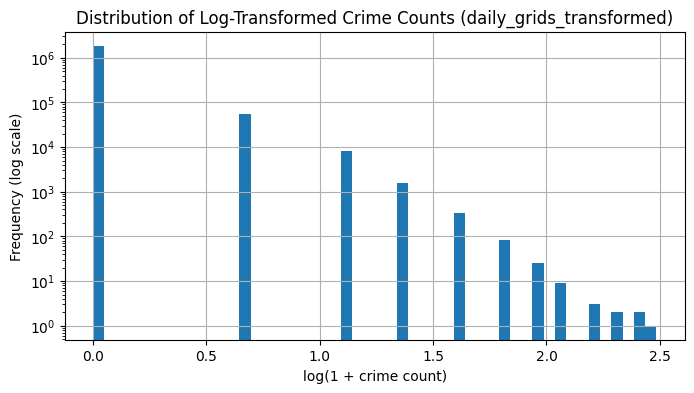

In [ ]:
print("\\n--- Checking Transformed Grids ---")
if 'daily_grids_transformed' in locals() and daily_grids_transformed.size > 0:
    print(f"Shape: {daily_grids_transformed.shape}")
    print(f"Min value: {daily_grids_transformed.min():.4f}")
    print(f"Max value: {daily_grids_transformed.max():.4f}")
    print(f"Mean value: {daily_grids_transformed.mean():.4f}")
    # Calculate sparsity: percentage of cells > 0
    sparsity = np.mean(daily_grids_transformed > 1e-6) # Use small threshold due to floats
    print(f"Sparsity (percentage of non-zero cells): {sparsity*100:.4f}%")
    # Check for NaNs
    nan_count = np.isnan(daily_grids_transformed).sum()
    print(f"NaN count: {nan_count}")

    # Visualize distribution
    plt.figure(figsize=(8,4))
    plt.hist(daily_grids_transformed.flatten(), bins=50, log=True) # Log scale for y-axis helps see small counts
    plt.title('Distribution of Log-Transformed Crime Counts (daily_grids_transformed)')
    plt.xlabel('log(1 + crime count)')
    plt.ylabel('Frequency (log scale)')
    plt.grid(True)
    plt.show()

else:
    print("daily_grids_transformed not found or empty.")

# PyTorch Dataset and DataLoader

In [ ]:
class CrimeDataset(Dataset):
    def __init__(self, Xc, Xd, Y):
        self.Xc = torch.FloatTensor(Xc)
        self.Xd = torch.FloatTensor(Xd)
        self.Y = torch.FloatTensor(Y)

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.Xc[idx], self.Xd[idx], self.Y[idx]

# Hyperparameters from paper (Section 5.2)
BATCH_SIZE = 32

if len(Y_train) > 0:
    train_dataset = CrimeDataset(Xc_train, Xd_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    print(f"Train DataLoader created with {len(train_loader)} batches.")
else:
    train_loader = None
    print("Train set is empty, DataLoader not created.")

if len(Y_test) > 0:
    test_dataset = CrimeDataset(Xc_test, Xd_test, Y_test)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    print(f"Test DataLoader created with {len(test_loader)} batches.")
else:
    test_loader = None
    print("Test set is empty, DataLoader not created.")

Train DataLoader created with 43 batches.
Test DataLoader created with 3 batches.


# ST-ACLCrime Model Implementation (PyTorch)

### Block 1: ConvLSTM Cell and Layer

In [ ]:
# Based on implementations found online, adapted for clarity

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        """
        Initialize ConvLSTM cell.
        Parameters
        ----------
        input_dim: int
            Number of channels of input tensor.
        hidden_dim: int
            Number of channels of hidden state.
        kernel_size: (int, int)
            Size of the convolutional kernel.
        bias: bool
            Whether or not to add the bias.
        """
        super(ConvLSTMCell, self).__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.padding = kernel_size[0] // 2, kernel_size[1] // 2
        self.bias = bias

        # Convolution for combined gates (input, forget, output, cell)
        self.conv = nn.Conv2d(in_channels=self.input_dim + self.hidden_dim,
                              out_channels=4 * self.hidden_dim, # 4 gates
                              kernel_size=self.kernel_size,
                              padding=self.padding,
                              bias=self.bias)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state

        # Concatenate input and hidden state along channel dimension
        combined = torch.cat([input_tensor, h_cur], dim=1)

        # Compute combined gates
        combined_conv = self.conv(combined)

        # Split combined gates into individual gates
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)

        # Apply activations
        i = torch.sigmoid(cc_i) # Input gate
        f = torch.sigmoid(cc_f) # Forget gate
        o = torch.sigmoid(cc_o) # Output gate
        g = torch.tanh(cc_g)    # Cell gate (candidate)

        # Calculate next cell state
        c_next = f * c_cur + i * g
        # Calculate next hidden state
        h_next = o * torch.tanh(c_next)

        return h_next, c_next

    def init_hidden(self, batch_size, image_size):
        height, width = image_size
        # Initialize hidden and cell states with zeros
        return (torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device),
                torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device))


class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bias=True):
        """
        Initialize ConvLSTM layer.
        Parameters
        ----------
        input_dim: int
            Number of channels of input tensor.
        hidden_dim: int or list
            Number of channels of hidden state for each layer.
        kernel_size: (int, int) or list
            Size of the convolutional kernel for each layer.
        num_layers: int
            Number of ConvLSTM layers.
        batch_first: bool
            If True, then the input and output tensors are provided as (batch, seq, channel, height, width).
        bias: bool
            Whether or not to add the bias.
        """
        super(ConvLSTM, self).__init__()

        self._check_kernel_size_consistency(kernel_size)

        # Make sure that both `kernel_size` and `hidden_dim` are lists having len == num_layers
        kernel_size = self._extend_for_multilayer(kernel_size, num_layers)
        hidden_dim = self._extend_for_multilayer(hidden_dim, num_layers)
        if not len(kernel_size) == len(hidden_dim) == num_layers:
            raise ValueError('Inconsistent list length.')

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.bias = bias

        cell_list = []
        for i in range(0, self.num_layers):
            cur_input_dim = self.input_dim if i == 0 else self.hidden_dim[i - 1]
            cell_list.append(ConvLSTMCell(input_dim=cur_input_dim,
                                          hidden_dim=self.hidden_dim[i],
                                          kernel_size=self.kernel_size[i],
                                          bias=self.bias))

        # ModuleList holds submodules in a list
        self.cell_list = nn.ModuleList(cell_list)

    def forward(self, input_tensor, hidden_state=None):
        """
        Parameters
        ----------
        input_tensor: torch.Tensor
            5-D Tensor either of shape (t, b, c, h, w) or (b, t, c, h, w)
        hidden_state: list of tuples, optional
            Initial hidden and cell states for each layer.

        Returns
        -------
        layer_output: torch.Tensor
             Output tensor of the last layer of shape (b, t, c_hidden, h, w)
        last_state_list: list of tuples
             List of (last_hidden_state, last_cell_state) for each layer
        """
        if not self.batch_first:
            # (t, b, c, h, w) -> (b, t, c, h, w)
            input_tensor = input_tensor.permute(1, 0, 2, 3, 4)

        b, seq_len, _, h, w = input_tensor.size()

        if hidden_state is None:
            # Initialize hidden state if not provided
            hidden_state = self._init_hidden(batch_size=b, image_size=(h, w))

        layer_output_list = []
        last_state_list = []

        cur_layer_input = input_tensor
        for layer_idx in range(self.num_layers):
            h, c = hidden_state[layer_idx]
            output_inner = []
            # Iterate over time steps
            for t in range(seq_len):
                h, c = self.cell_list[layer_idx](input_tensor=cur_layer_input[:, t, :, :, :],
                                                 cur_state=[h, c])
                output_inner.append(h)

            layer_output = torch.stack(output_inner, dim=1) # Stack along time dimension
            cur_layer_input = layer_output # Output of current layer is input to next layer

            layer_output_list.append(layer_output)
            last_state_list.append((h, c)) # Keep last hidden and cell state

        layer_output = layer_output_list[-1]

        return layer_output, last_state_list

    def _init_hidden(self, batch_size, image_size):
        init_states = []
        for i in range(self.num_layers):
            init_states.append(self.cell_list[i].init_hidden(batch_size, image_size))
        return init_states

    @staticmethod
    def _check_kernel_size_consistency(kernel_size):
        if not (isinstance(kernel_size, tuple) or
                (isinstance(kernel_size, list) and all([isinstance(elem, tuple) for elem in kernel_size]))):
            raise ValueError('`kernel_size` must be tuple or list of tuples')

    @staticmethod
    def _extend_for_multilayer(param, num_layers):
        if not isinstance(param, list):
            param = [param] * num_layers
        return param

### Block 2: Squeeze-and-Excitation (SE) Block

In [ ]:
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        """
        Initialize Squeeze-and-Excitation Block.
        Parameters
        ----------
        channel: int
            Number of input channels.
        reduction: int
            Reduction ratio for the intermediate layer dimension.
        """
        super(SEBlock, self).__init__()
        # Squeeze: Global Average Pooling
        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        # Excitation: Two Fully Connected layers (implemented as 1x1 Convs)
        self.fc = nn.Sequential(
            nn.Conv2d(channel, channel // reduction, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channel // reduction, channel, kernel_size=1, bias=False),
            nn.Sigmoid() # Outputs channel weights between 0 and 1
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        # Squeeze
        y = self.avg_pool(x) # shape: (b, c, 1, 1)
        # Excitation
        y = self.fc(y) # shape: (b, c, 1, 1) - channel weights
        # Scale (Fscale)
        return x * y.expand_as(x) # Broadcast weights to original feature map size

### Block 3: ST-ACLCrime Model Definition

In [ ]:
class ST_ACLCrime(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, convlstm_kernel_size, convlstm_num_layers,
                 cnn_kernel_size, grid_height, grid_width, se_reduction=16, bias=True):
        """
        Initialize the ST-ACLCrime model.
        Parameters same as Block 4 in previous response.
        """
        super(ST_ACLCrime, self).__init__()

        self.hidden_dim = hidden_dim
        self.grid_height = grid_height
        self.grid_width = grid_width

        cnn_padding = cnn_kernel_size[0] // 2, cnn_kernel_size[1] // 2

        # --- Define layers for one branch (Closeness/Period) ---
        # Structure follows Fig 1: CNN -> ConvLSTM -> ConvLSTM -> SE Block -> CNN
        # Note: Paper figure shows 2 ConvLSTM layers. Adjust convlstm_num_layers if needed.
        # We use num_layers parameter in ConvLSTM class to handle stacking.

        self.initial_cnn = nn.Sequential(
            nn.Conv2d(in_channels=input_dim, out_channels=hidden_dim,
                      kernel_size=cnn_kernel_size, padding=cnn_padding, bias=bias),
            nn.ReLU()
        )

        self.convlstm = ConvLSTM(input_dim=hidden_dim,
                                 hidden_dim=hidden_dim,
                                 kernel_size=convlstm_kernel_size,
                                 num_layers=convlstm_num_layers,
                                 batch_first=True,
                                 bias=bias)

        self.se_block = SEBlock(channel=hidden_dim, reduction=se_reduction)

        self.final_cnn = nn.Sequential(
            nn.Conv2d(in_channels=hidden_dim, out_channels=output_dim,
                      kernel_size=cnn_kernel_size, padding=cnn_padding, bias=bias),
            nn.ReLU() # Use ReLU for non-negative crime counts prediction
        )
        # --- End of branch definition ---

        # Learnable weights for dynamic fusion (Parametric-matrix approach)
        self.Wc = nn.Parameter(torch.ones(1, output_dim, grid_height, grid_width) * 0.5)
        self.Wd = nn.Parameter(torch.ones(1, output_dim, grid_height, grid_width) * 0.5)

    def forward_branch(self, x_seq):
        # x_seq shape: (batch, seq_len, channels_in, height, width)
        b, seq_len, c_in, h, w = x_seq.size()

        # Apply initial CNN to each time step independently
        x_cnn_in = x_seq.view(b * seq_len, c_in, h, w)
        x_cnn_out = self.initial_cnn(x_cnn_in)
        _, c_hidden, h_cnn, w_cnn = x_cnn_out.size()
        x_convlstm_in = x_cnn_out.view(b, seq_len, c_hidden, h_cnn, w_cnn)

        # Apply ConvLSTM
        layer_output, last_states = self.convlstm(x_convlstm_in)

        # Get hidden state of the last time step of the last layer
        last_hidden_state = last_states[-1][0] # Shape: (b, c_hidden, h, w)

        # Apply SE Block
        se_output = self.se_block(last_hidden_state) # Shape: (b, c_hidden, h, w)

        # Apply final CNN
        branch_output = self.final_cnn(se_output) # Shape: (b, c_out, h, w)

        return branch_output

    def forward(self, Xc, Xd):
        """
        Forward pass of the ST-ACLCrime model.
        """
        out_c = self.forward_branch(Xc) # Closeness branch output
        out_d = self.forward_branch(Xd) # Period branch output

        # Dynamic Fusion (Eq. 4: Weighted sum)
        output = self.Wc * out_c + self.Wd * out_d

        return output

# Model Training

### Hyperparameters & Instantiation

In [ ]:
# Check if grid dimensions are valid
if GRID_H <= 0 or GRID_W <= 0:
    print("Grid dimensions are invalid. Cannot instantiate model.")
    model = None
else:
    # Model Hyperparameters (Adjust based on paper/data/grid size)
    INPUT_CHANNELS = 1  # Crime count map
    HIDDEN_CHANNELS = 64 # Mentioned in paper (Section 5.2)
    OUTPUT_CHANNELS = 1 # Predict crime count map
    CONVLSTM_KERNEL = (3, 3) # Common choice
    CONVLSTM_LAYERS = 2  # As potentially implied by Fig 1
    CNN_KERNEL = (3, 3) # Common choice
    SE_REDUCTION = 16    # Common choice

    # Training Hyperparameters from paper (Section 5.2)
    LEARNING_RATE = 0.0001
    NUM_EPOCHS = 100 # Paper used 100, adjust for faster testing if needed

    # Instantiate the model
    model = ST_ACLCrime(
        input_dim=INPUT_CHANNELS,
        hidden_dim=HIDDEN_CHANNELS,
        output_dim=OUTPUT_CHANNELS,
        convlstm_kernel_size=CONVLSTM_KERNEL,
        convlstm_num_layers=CONVLSTM_LAYERS,
        cnn_kernel_size=CNN_KERNEL,
        grid_height=GRID_H,
        grid_width=GRID_W,
        se_reduction=SE_REDUCTION
    ).to(device)

    #print(model)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model Instantiated on {device}.")
    print(f"Grid Size (H, W): ({GRID_H}, {GRID_W})")
    print(f"Total Trainable Parameters: {total_params:,}")

    # Define Loss and Optimizer (as per paper Section 5.2)
    criterion = nn.MSELoss() # Mean Squared Error Loss
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

Model Instantiated on cuda.
Grid Size (H, W): (47, 28)
Total Trainable Parameters: 594,697


### Training Loop


Starting Training...


Epoch 1/100:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch [1/100], Average Loss: 0.020193


Epoch 2/100:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch [2/100], Average Loss: 0.019557


...

Epoch [98/100], Average Loss: 0.018777


Epoch 99/100:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch [99/100], Average Loss: 0.018785


Epoch 100/100:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch [100/100], Average Loss: 0.018785

Training Finished.


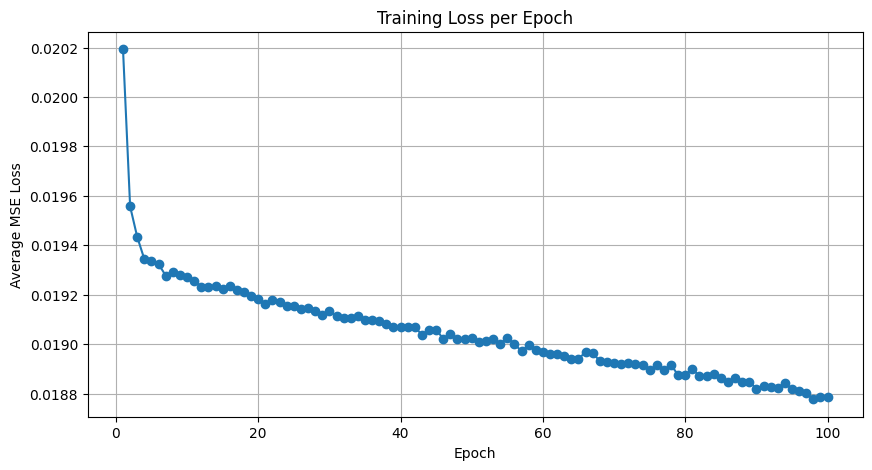

In [ ]:
train_losses = []

if model is not None and train_loader is not None:
    print("\nStarting Training...")
    model.train() # Set model to training mode

    for epoch in range(NUM_EPOCHS):
        epoch_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=False)

        for xc_batch, xd_batch, y_batch in progress_bar:
            # Move data to device
            xc_batch = xc_batch.to(device)
            xd_batch = xd_batch.to(device)
            y_batch = y_batch.to(device)

            # 1. Forward pass
            outputs = model(xc_batch, xd_batch)

            # 2. Calculate loss
            loss = criterion(outputs, y_batch)

            # 3. Zero gradients, backward pass, update weights
            optimizer.zero_grad()
            loss.backward()

            # --- Add Gradient Check ---
            total_norm = 0
            grad_mags = {}
            for name, p in model.named_parameters():
                if p.grad is not None:
                    param_norm = p.grad.detach().data.norm(2)
                    total_norm += param_norm.item() ** 2
                    if 'convlstm.cell_list.0.conv.weight' in name: # Example: first convlstm cell
                        grad_mags['convlstm0_grad_mean'] = p.grad.abs().mean().item()
                    if 'final_cnn.0.weight' in name: # Example: first layer of final cnn
                        grad_mags['finalcnn_grad_mean'] = p.grad.abs().mean().item()
                    if 'Wc' in name: # Fusion weight
                        grad_mags['Wc_grad_mean'] = p.grad.abs().mean().item()

            total_norm = total_norm ** 0.5
            # --- End Gradient Check ---

            optimizer.step()

            epoch_loss += loss.item()
            postfix_dict = {'loss': loss.item(), 'grad_norm': total_norm}
            postfix_dict.update(grad_mags) # Add specific layer grads if collected
            progress_bar.set_postfix(postfix_dict)

        avg_epoch_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_epoch_loss)
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Average Loss: {avg_epoch_loss:.6f}')
        # Optional: Print fusion weights
        # print(f"  Wc mean: {model.Wc.mean().item():.4f}, Wd mean: {model.Wd.mean().item():.4f}")

    print("\nTraining Finished.")

    # Plot training loss
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o')
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Average MSE Loss')
    plt.grid(True)
    plt.show()

else:
    print("Model or DataLoader not available. Skipping training.")

### Save Model

In [ ]:
import torch
import os

# --- Define Save Path ---
MODEL_SAVE_DIR = '/content/drive/MyDrive/models' # Directory to save models
MODEL_FILENAME = 'st_aclcrim__theft_model_state.pth'
MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, MODEL_FILENAME)

# Create directory if it doesn't exist
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# --- Check if model exists and is trained ---
if 'model' in locals() and model is not None and 'train_losses' in locals() and len(train_losses) > 0:
    print(f"\nSaving model state dictionary to: {MODEL_SAVE_PATH}")

    # It's generally good practice to save the model state dict on the CPU
    # model.to('cpu') # Optional: Move model to CPU before saving state

    # Save only the model's parameters (state_dict)
    torch.save(model.state_dict(), MODEL_SAVE_PATH)

    print("Model state dictionary saved successfully.")

    # Optional: Move model back to original device if needed for further steps
    # model.to(device)

    # --- Save Hyperparameters (Crucial for Reloading) ---
    # We need GRID_H and GRID_W specifically, others might be hardcoded or derivable
    hyperparams = {
        'GRID_H': GRID_H if 'GRID_H' in locals() else None,
        'GRID_W': GRID_W if 'GRID_W' in locals() else None,
        'INPUT_CHANNELS': INPUT_CHANNELS if 'INPUT_CHANNELS' in locals() else 1,
        'HIDDEN_CHANNELS': HIDDEN_CHANNELS if 'HIDDEN_CHANNELS' in locals() else 64,
        'OUTPUT_CHANNELS': OUTPUT_CHANNELS if 'OUTPUT_CHANNELS' in locals() else 1,
        'CONVLSTM_KERNEL': CONVLSTM_KERNEL if 'CONVLSTM_KERNEL' in locals() else (3,3),
        'CONVLSTM_LAYERS': CONVLSTM_LAYERS if 'CONVLSTM_LAYERS' in locals() else 2,
        'CNN_KERNEL': CNN_KERNEL if 'CNN_KERNEL' in locals() else (3,3),
        'SE_REDUCTION': SE_REDUCTION if 'SE_REDUCTION' in locals() else 16
    }
    hyperparam_path = os.path.join(MODEL_SAVE_DIR, 'model_hyperparams.pth')
    torch.save(hyperparams, hyperparam_path)
    print(f"Model hyperparameters saved to: {hyperparam_path}")
    if hyperparams['GRID_H'] is None or hyperparams['GRID_W'] is None:
         print("Warning: GRID_H or GRID_W not found, saving None. You MUST know these to reload.")

elif 'model' not in locals() or model is None:
     print("\nSkipping model saving: Model object 'model' does not exist.")
else:
     print("\nSkipping model saving: Model does not appear to have been trained (no 'train_losses').")

### Load Saved Model

In [ ]:
import torch
import os

# --- Define Load Path (must match save path) ---
MODEL_SAVE_DIR = '/content/drive/MyDrive/models'
MODEL_FILENAME = 'st_aclcrim__theft_model_state.pth'
MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, MODEL_FILENAME)
hyperparam_path = os.path.join(MODEL_SAVE_DIR, 'model_hyperparams.pth')

# --- Check if saved files exist ---
if os.path.exists(MODEL_SAVE_PATH) and os.path.exists(hyperparam_path):
    print(f"Loading hyperparameters from: {hyperparam_path}")
    loaded_hyperparams = torch.load(hyperparam_path)

    # Retrieve necessary hyperparameters
    LOADED_GRID_H = loaded_hyperparams.get('GRID_H')
    LOADED_GRID_W = loaded_hyperparams.get('GRID_W')
    LOADED_INPUT_CHANNELS = loaded_hyperparams.get('INPUT_CHANNELS', 1) # Default if missing
    LOADED_HIDDEN_CHANNELS = loaded_hyperparams.get('HIDDEN_CHANNELS', 64)
    LOADED_OUTPUT_CHANNELS = loaded_hyperparams.get('OUTPUT_CHANNELS', 1)
    LOADED_CONVLSTM_KERNEL = loaded_hyperparams.get('CONVLSTM_KERNEL', (3,3))
    LOADED_CONVLSTM_LAYERS = loaded_hyperparams.get('CONVLSTM_LAYERS', 2)
    LOADED_CNN_KERNEL = loaded_hyperparams.get('CNN_KERNEL', (3,3))
    LOADED_SE_REDUCTION = loaded_hyperparams.get('SE_REDUCTION', 16)

    if LOADED_GRID_H is None or LOADED_GRID_W is None:
        print("ERROR: Saved hyperparameters missing GRID_H or GRID_W. Cannot load model.")
        loaded_model = None
    else:
        print(f"Loaded Grid Dimensions: H={LOADED_GRID_H}, W={LOADED_GRID_W}")
        # --- Instantiate a new model with the SAME architecture ---
        # Ensure the ST_ACLCrime class definition is available!
        loaded_model = ST_ACLCrime(
            input_dim=LOADED_INPUT_CHANNELS,
            hidden_dim=LOADED_HIDDEN_CHANNELS,
            output_dim=LOADED_OUTPUT_CHANNELS,
            convlstm_kernel_size=LOADED_CONVLSTM_KERNEL,
            convlstm_num_layers=LOADED_CONVLSTM_LAYERS,
            cnn_kernel_size=LOADED_CNN_KERNEL,
            grid_height=LOADED_GRID_H,
            grid_width=LOADED_GRID_W,
            se_reduction=LOADED_SE_REDUCTION
        )

        # --- Load the saved state dictionary ---
        print(f"Loading model state dictionary from: {MODEL_SAVE_PATH}")
        # Load onto the current device (CPU or GPU)
        loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))

        # --- Move model to the appropriate device ---
        loaded_model.to(device)

        # --- Set the model to evaluation mode ---
        # This is crucial: disables dropout, batch norm updates etc.
        loaded_model.eval()

        print("Model loaded successfully and set to evaluation mode.")

else:
    print(f"ERROR: Model state file '{MODEL_SAVE_PATH}' or hyperparameter file '{hyperparam_path}' not found. Cannot load model.")
    loaded_model = None

# Model Evaluation

In [ ]:
all_preds = []
all_targets = []

if model is not None and test_loader is not None:
    print("\nStarting Evaluation...")
    model.eval() # Set model to evaluation mode
    test_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations
        for xc_batch, xd_batch, y_batch in tqdm(test_loader, desc='Evaluating', leave=False):
            xc_batch = xc_batch.to(device)
            xd_batch = xd_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(xc_batch, xd_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()

            # Store predictions and targets for metric calculation
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    avg_test_loss = test_loss / len(test_loader)
    print(f"\nAverage Test MSE Loss: {avg_test_loss:.6f}")

    # Concatenate predictions and targets from all batches
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    # --- Add this section for Inverse Transformation ---
    # Apply inverse transform exp(x) - 1 to predictions and targets
    # Ensure targets are also transformed back if they were stored transformed
    all_preds_orig_scale = np.expm1(all_preds)
    all_targets_orig_scale = np.expm1(all_targets)

    # Ensure non-negativity after inverse transform (due to potential float inaccuracies)
    all_preds_orig_scale[all_preds_orig_scale < 0] = 0
    # --- Use *_orig_scale variables below for metrics ---


    # --- Calculate Metrics (MAE, RMSE) ---
    # Flatten the spatial dimensions for sklearn metrics if needed, or calculate per-grid-cell metrics
    # Here, calculate overall MAE and RMSE across all predicted cells
    mae = mean_absolute_error(all_targets_orig_scale.flatten(), all_preds_orig_scale.flatten())
    rmse = np.sqrt(mean_squared_error(all_targets_orig_scale.flatten(), all_preds_orig_scale.flatten()))

    print(f"Test MAE: {mae:.6f}")
    print(f"Test RMSE: {rmse:.6f}")

    # --- Mean Hit Rate (Placeholder/Concept) ---
    # Calculation requires defining hotspots (e.g., top N% predicted cells)
    # And comparing true counts in those cells vs total true count.
    def calculate_mean_hit_rate(preds, targets, coverage_percentage=0.20):
        num_samples, _, h, w = preds.shape
        num_cells = h * w
        top_n = int(np.ceil(num_cells * coverage_percentage))
        hit_rates = []

        for i in range(num_samples):
            pred_flat = preds[i, 0].flatten()
            target_flat = targets[i, 0].flatten()

            # Get indices of top N predicted cells
            top_indices = np.argsort(pred_flat)[-top_n:]

            # Sum of true crimes in the top N predicted cells
            true_crimes_in_hotspots = np.sum(target_flat[top_indices])
            total_true_crimes = np.sum(target_flat)

            if total_true_crimes > 0:
                hit_rate = true_crimes_in_hotspots / total_true_crimes
                hit_rates.append(hit_rate)
            elif true_crimes_in_hotspots == 0: # If no true crime and no predicted crime in top N, count as perfect hit?
                 hit_rates.append(1.0)
            else: # No true crime but predicted some in top N
                 hit_rates.append(0.0)

        return np.mean(hit_rates) * 100 if hit_rates else 0

    mhr_10 = calculate_mean_hit_rate(all_preds_orig_scale, all_targets_orig_scale, 0.10)
    mhr_20 = calculate_mean_hit_rate(all_preds_orig_scale, all_targets_orig_scale, 0.20)
    print(f"Test Mean Hit Rate @10%: {mhr_10:.2f}%")
    print(f"Test Mean Hit Rate @20%: {mhr_20:.2f}%")

else:
    print("Model or DataLoader not available. Skipping evaluation.")


Starting Evaluation...


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]


Average Test MSE Loss: 0.015340
Test MAE: 0.053853
Test RMSE: 0.210809
Test Mean Hit Rate @10%: 48.20%
Test Mean Hit Rate @20%: 71.08%


## Baseline Mean Hit Rate


--- Calculating Baseline Hit Rate (Static Historical Hotspots) ---
Calculated historical total grid. Shape: (47, 28), Max count: 1239.0
Total cells: 1316


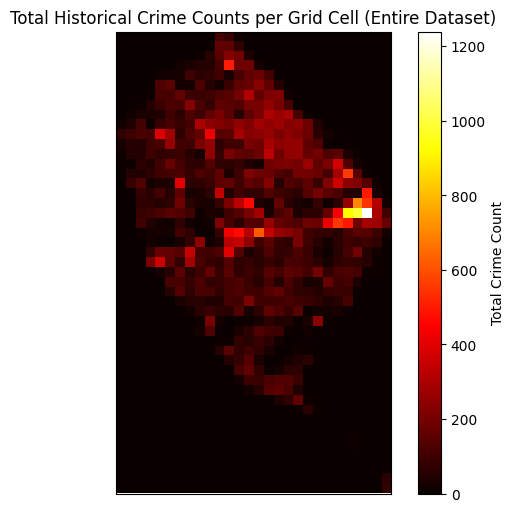

Identifying top 132 historically highest cells (10.0% coverage)...
Evaluating baseline against 70 test days...
Identifying top 264 historically highest cells (20.0% coverage)...
Evaluating baseline against 70 test days...

Baseline Mean Hit Rate @10% (Historical Hotspots): 50.67%
Baseline Mean Hit Rate @20% (Historical Hotspots): 73.96%

--- Comparison ---
Model   MHR@10%: 48.20%  | Baseline MHR@10%: 50.67%
Model   MHR@20%: 71.08%  | Baseline MHR@20%: 73.96%


In [ ]:

# --- Baseline Hit Rate Calculation ---
print("\n--- Calculating Baseline Hit Rate (Static Historical Hotspots) ---")

# Check if necessary data exists from previous cells
if 'daily_grids' in locals() and 'all_targets_orig_scale' in locals() and 'GRID_H' in locals() and 'GRID_W' in locals() and len(daily_grids) > 0 and len(all_targets_orig_scale) > 0:

    # 1. Calculate the overall historical crime grid (sum across all days)
    #    Use the original 'daily_grids' *before* log transformation
    historical_total_grid = np.sum(daily_grids, axis=0)
    historical_total_flat = historical_total_grid.flatten()
    num_cells = GRID_H * GRID_W

    print(f"Calculated historical total grid. Shape: {historical_total_grid.shape}, Max count: {historical_total_grid.max()}")
    print(f"Total cells: {num_cells}")

    # Optional: Visualize the historical total grid
    plt.figure(figsize=(7, 6))
    plt.imshow(historical_total_grid, cmap='hot', interpolation='nearest')
    plt.title('Total Historical Crime Counts per Grid Cell (Entire Dataset)')
    plt.colorbar(label='Total Crime Count')
    plt.xticks([])
    plt.yticks([])
    plt.show()

    # 2. Define function to calculate baseline hit rate for a given coverage
    def calculate_baseline_hit_rate(historical_flat, targets_orig_scale, num_cells, coverage_percentage):
        top_n = int(np.ceil(num_cells * coverage_percentage))
        if top_n == 0 and num_cells > 0:
             top_n = 1 # Ensure at least one cell is selected if possible
        if top_n == 0:
             print(f"Warning: Cannot select top {coverage_percentage*100}% cells (num_cells={num_cells}).")
             return 0.0

        print(f"Identifying top {top_n} historically highest cells ({coverage_percentage*100:.1f}% coverage)...")
        # Get indices of the top N historically highest cells
        historical_hotspot_indices = np.argsort(historical_flat)[-top_n:]

        daily_hit_rates = []
        num_test_days = targets_orig_scale.shape[0]

        print(f"Evaluating baseline against {num_test_days} test days...")
        for i in range(num_test_days):
            target_grid_flat = targets_orig_scale[i, 0].flatten() # Targets are (N, 1, H, W)

            # Sum of true crimes on this day in the *historically* determined hotspots
            true_crimes_in_historical_hotspots = np.sum(target_grid_flat[historical_hotspot_indices])
            total_true_crimes_today = np.sum(target_grid_flat)

            # Calculate hit rate for the day (same logic as in model evaluation)
            if total_true_crimes_today > 0:
                hit_rate = true_crimes_in_historical_hotspots / total_true_crimes_today
                daily_hit_rates.append(hit_rate)
            elif true_crimes_in_historical_hotspots == 0: # No crime today, and none in predicted spots = perfect?
                 daily_hit_rates.append(1.0)
            else: # No crime today, but historical spots had counts > 0 (irrelevant for hit rate)
                 daily_hit_rates.append(0.0) # Actually, should be 1.0 if true_crimes_in_historical_hotspots is also 0

        # Calculate the mean hit rate across all test days
        mean_hit_rate = np.mean(daily_hit_rates) * 100 if daily_hit_rates else 0
        return mean_hit_rate

    # 3. Calculate and print baseline hit rates for 10% and 20%
    baseline_mhr_10 = calculate_baseline_hit_rate(historical_total_flat, all_targets_orig_scale, num_cells, 0.10)
    baseline_mhr_20 = calculate_baseline_hit_rate(historical_total_flat, all_targets_orig_scale, num_cells, 0.20)

    print(f"\nBaseline Mean Hit Rate @10% (Historical Hotspots): {baseline_mhr_10:.2f}%")
    print(f"Baseline Mean Hit Rate @20% (Historical Hotspots): {baseline_mhr_20:.2f}%")

    # Compare with model results if available
    if 'mhr_10' in locals() and 'mhr_20' in locals():
        print("\n--- Comparison ---")
        print(f"Model   MHR@10%: {mhr_10:.2f}%  | Baseline MHR@10%: {baseline_mhr_10:.2f}%")
        print(f"Model   MHR@20%: {mhr_20:.2f}%  | Baseline MHR@20%: {baseline_mhr_20:.2f}%")

else:
    print("\nSkipping Baseline Hit Rate calculation: Required data ('daily_grids', 'all_targets_orig_scale', 'GRID_H', 'GRID_W') not found or empty.")

# Prediction Visualization

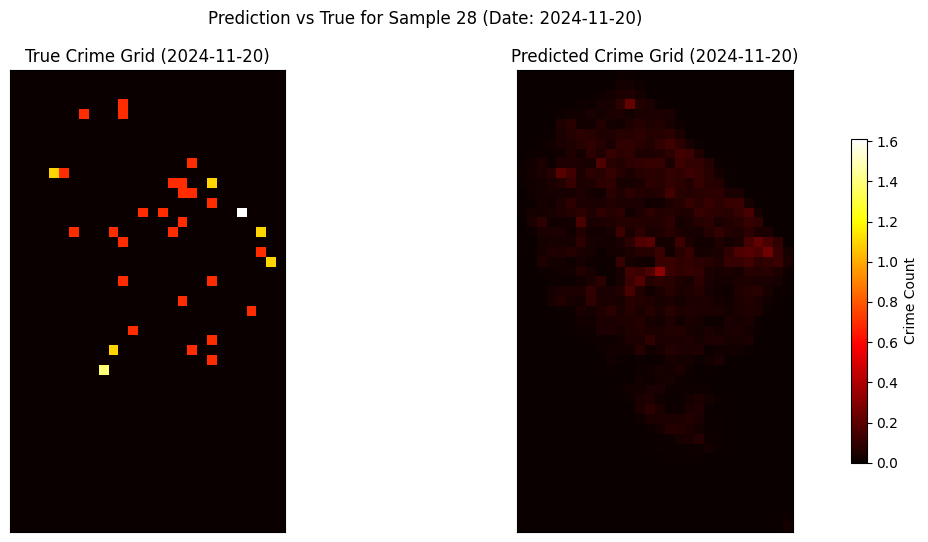

In [ ]:
if model is not None and test_loader is not None and len(all_preds) > 0:
    # Visualize prediction for a sample from the test set
    sample_idx = np.random.randint(0, len(all_targets)) # Choose a random test sample

    pred_grid = all_preds[sample_idx, 0, :, :]
    true_grid = all_targets[sample_idx, 0, :, :]
    pred_date = T_test[sample_idx].date()

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    vmax = max(np.max(pred_grid), np.max(true_grid)) # Consistent color scale

    im0 = axes[0].imshow(true_grid, cmap='hot', interpolation='nearest', vmin=0, vmax=vmax)
    axes[0].set_title(f'True Crime Grid ({pred_date})')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    im1 = axes[1].imshow(pred_grid, cmap='hot', interpolation='nearest', vmin=0, vmax=vmax)
    axes[1].set_title(f'Predicted Crime Grid ({pred_date})')
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.7, label='Crime Count')
    plt.suptitle(f'Prediction vs True for Sample {sample_idx} (Date: {pred_date})')
    plt.show()
else:
    print("Cannot visualize predictions. No test data or predictions available.")

### Visualize Predictions Over Consecutive Test Days

\nVisualizing True vs. Predicted Grids for 5 consecutive test days starting from index 0...


<ipython-input-25-1ac1d35d988a>:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


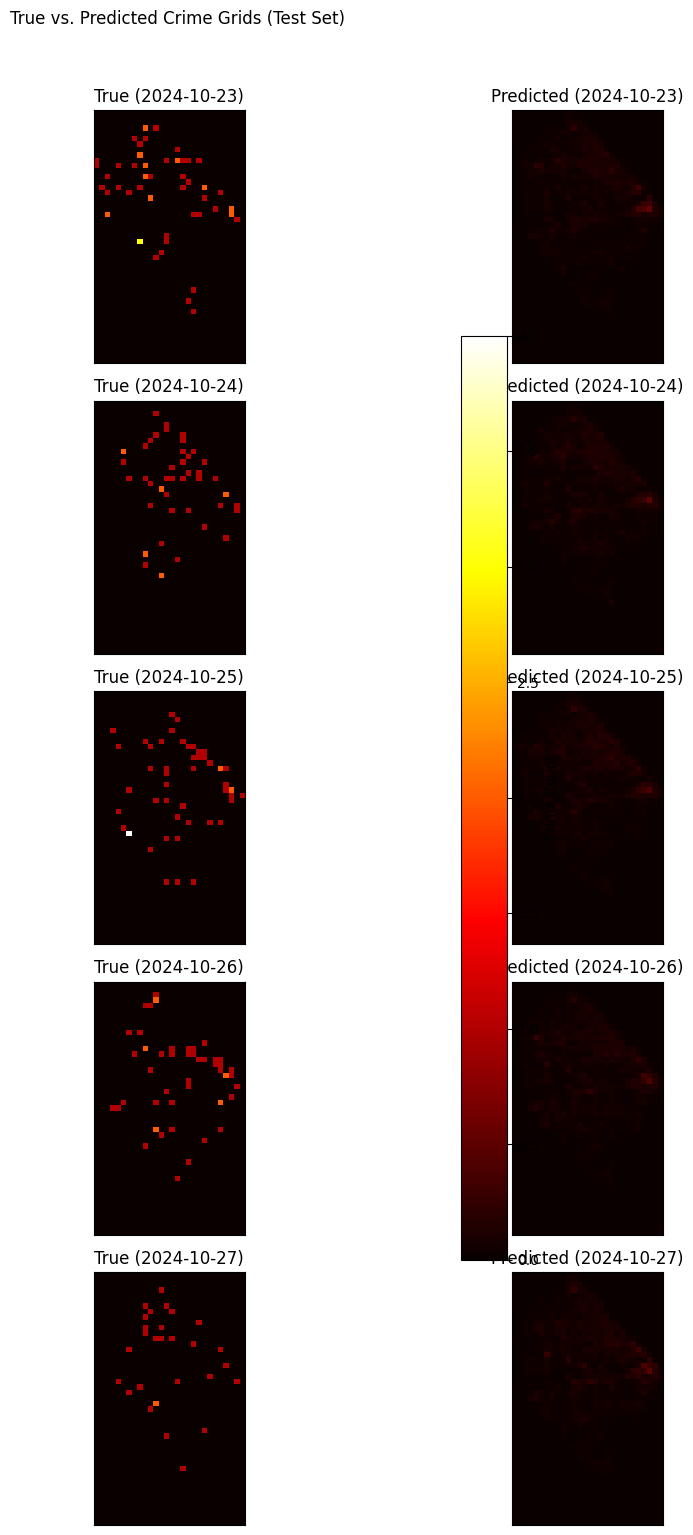

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Parameters for Visualization ---
num_days_to_plot = 5  # How many consecutive days to show
start_day_index = 0 # Start from the beginning of the test set (0) or choose another index

if 'all_preds_orig_scale' in locals() and len(all_preds_orig_scale) > start_day_index + num_days_to_plot:
    print(f"\\nVisualizing True vs. Predicted Grids for {num_days_to_plot} consecutive test days starting from index {start_day_index}...")

    # Determine a consistent color scale across the selected plots
    max_val_pred = np.max(all_preds_orig_scale[start_day_index : start_day_index + num_days_to_plot])
    max_val_true = np.max(all_targets_orig_scale[start_day_index : start_day_index + num_days_to_plot])
    vmax = max(max_val_pred, max_val_true, 1) # Use at least 1 to avoid issues with all zeros

    fig, axes = plt.subplots(num_days_to_plot, 2, figsize=(10, 3 * num_days_to_plot))
    if num_days_to_plot == 1: # Handle case of single day plot
        axes = np.array([axes])

    for i in range(num_days_to_plot):
        day_index = start_day_index + i
        true_grid = all_targets_orig_scale[day_index, 0, :, :]
        pred_grid = all_preds_orig_scale[day_index, 0, :, :]
        pred_date = T_test[day_index].date()

        # Plot True Grid
        im_true = axes[i, 0].imshow(true_grid, cmap='hot', interpolation='nearest', vmin=0, vmax=vmax)
        axes[i, 0].set_title(f'True ({pred_date})')
        axes[i, 0].set_xticks([])
        axes[i, 0].set_yticks([])

        # Plot Predicted Grid
        im_pred = axes[i, 1].imshow(pred_grid, cmap='hot', interpolation='nearest', vmin=0, vmax=vmax)
        axes[i, 1].set_title(f'Predicted ({pred_date})')
        axes[i, 1].set_xticks([])
        axes[i, 1].set_yticks([])

    # Add a single colorbar
    fig.colorbar(im_pred, ax=axes.ravel().tolist(), shrink=0.8, label='Crime Count')
    plt.suptitle('True vs. Predicted Crime Grids (Test Set)', y=1.02)
    plt.tight_layout()
    plt.show()

else:
    print("\\nSkipping prediction visualization: Not enough test predictions available.")

### Residual Analysis

In [ ]:
!pip install libpysal
!pip install esda
!pip install splot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.8/142.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.2/388.2 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.7/322.7 kB 30.1 MB/s eta 0:00:00



Starting Residual Analysis...
Residuals shape: (70, 1, 47, 28)

--- Temporal Autocorrelation ---


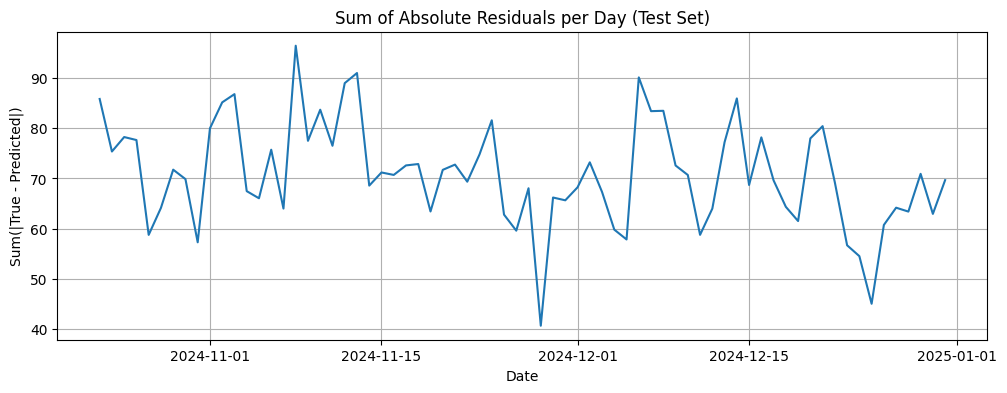

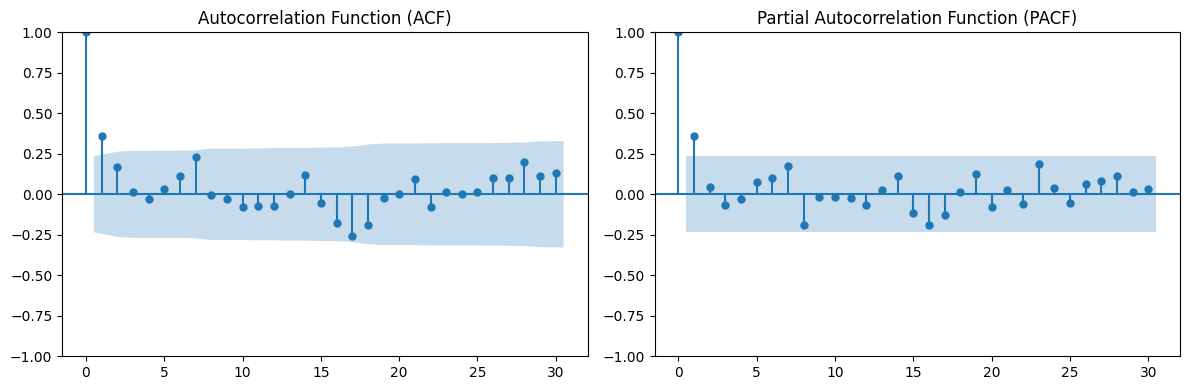

Interpretation: Spikes outside the blue confidence band indicate significant autocorrelation at that lag.
Ideally, most/all spikes should be within the band for random residuals.

Ljung-Box Test for Autocorrelation:
      lb_stat  lb_pvalue
7   17.090208   0.016824
14  19.880645   0.133950
Interpretation: Small lb_pvalue (e.g., < 0.05) suggests significant autocorrelation exists.

--- Spatial Autocorrelation ---


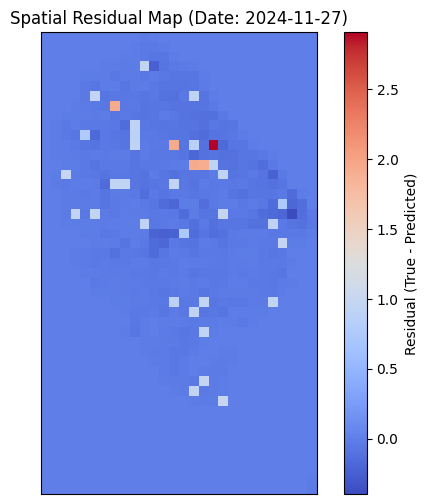


Global Moran's I for Residuals (Date: 2024-11-27):
  Moran's I statistic: -0.0052
  P-value (pseudo):   0.3960
  Z-score (pseudo):   -0.3521
Interpretation:
  - Positive significant I: Clustering of similar residuals (high near high, low near low).
  - Negative significant I: Dispersion/Checkerboard pattern of residuals.
  - Non-significant I: Residuals are spatially random.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import libpysal.weights
import esda
import splot.esda

print("\nStarting Residual Analysis...")

if 'all_preds_orig_scale' in locals() and len(all_preds_orig_scale) > 1: # Need >1 for time series analysis
    # --- Calculate Residuals ---
    residuals = all_targets_orig_scale - all_preds_orig_scale
    print(f"Residuals shape: {residuals.shape}") # (num_test_days, 1, H, W)

    # --- 1. Temporal Autocorrelation Analysis ---
    print("\n--- Temporal Autocorrelation ---")
    # Aggregate residuals per day (e.g., sum of absolute residuals)
    daily_residual_sum_abs = np.sum(np.abs(residuals), axis=(1, 2, 3))

    # Plot the daily residual sum
    plt.figure(figsize=(12, 4))
    plt.plot(T_test, daily_residual_sum_abs)
    plt.title('Sum of Absolute Residuals per Day (Test Set)')
    plt.xlabel('Date')
    plt.ylabel('Sum(|True - Predicted|)')
    plt.grid(True)
    plt.show()

    # Plot ACF and PACF
    try:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        plot_acf(daily_residual_sum_abs, ax=axes[0], lags=min(30, len(daily_residual_sum_abs)//2 - 1)) # Show up to 30 lags or half the series
        plot_pacf(daily_residual_sum_abs, ax=axes[1], lags=min(30, len(daily_residual_sum_abs)//2 - 1), method='ywm')
        axes[0].set_title('Autocorrelation Function (ACF)')
        axes[1].set_title('Partial Autocorrelation Function (PACF)')
        plt.tight_layout()
        plt.show()
        print("Interpretation: Spikes outside the blue confidence band indicate significant autocorrelation at that lag.")
        print("Ideally, most/all spikes should be within the band for random residuals.")

        # Ljung-Box test (optional statistical test)
        ljung_box_result = acorr_ljungbox(daily_residual_sum_abs, lags=[7, 14], return_df=True) # Test for weekly/bi-weekly lags
        print("\nLjung-Box Test for Autocorrelation:")
        print(ljung_box_result)
        print("Interpretation: Small lb_pvalue (e.g., < 0.05) suggests significant autocorrelation exists.")

    except Exception as e:
        print(f"Could not generate ACF/PACF plots or Ljung-Box test: {e}")


    # --- 2. Spatial Autocorrelation Analysis ---
    print("\n--- Spatial Autocorrelation ---")
    if GRID_H > 1 and GRID_W > 1: # Need spatial dimensions
        # Choose a day to analyze spatially (e.g., middle of test set)
        spatial_day_index = len(residuals) // 2
        residual_map = residuals[spatial_day_index, 0, :, :]
        residual_map_flat = residual_map.flatten()

        # Plot the residual map for the chosen day
        plt.figure(figsize=(7, 6))
        plt.imshow(residual_map, cmap='coolwarm', interpolation='nearest')
        plt.colorbar(label='Residual (True - Predicted)')
        plt.title(f'Spatial Residual Map (Date: {T_test[spatial_day_index].date()})')
        plt.xticks([])
        plt.yticks([])
        plt.show()

        # Calculate Global Moran's I
        try:
            # Create spatial weights matrix (Queen contiguity)
            w = libpysal.weights.lat2W(GRID_H, GRID_W, rook=False) # rook=False means Queen
            w.transform = 'R' # Row-standardize weights

            # Calculate Moran's I statistic
            moran = esda.moran.Moran(residual_map_flat, w)
            print(f"\nGlobal Moran's I for Residuals (Date: {T_test[spatial_day_index].date()}):")
            print(f"  Moran's I statistic: {moran.I:.4f}")
            print(f"  P-value (pseudo):   {moran.p_sim:.4f}")
            print(f"  Z-score (pseudo):   {moran.z_sim:.4f}")
            print("Interpretation:")
            print("  - Positive significant I: Clustering of similar residuals (high near high, low near low).")
            print("  - Negative significant I: Dispersion/Checkerboard pattern of residuals.")
            print("  - Non-significant I: Residuals are spatially random.")

            # Optional: Plot Local Moran's I map (identifies clusters)
            # moran_loc = esda.moran.Moran_Local(residual_map_flat, w)
            # fig, ax = splot.esda.plot_local_moran(moran_loc, residual_map_flat, w, figsize=(10,10))
            # plt.suptitle(f"Local Moran's I for Residuals (Date: {T_test[spatial_day_index].date()})")
            # plt.show()

        except Exception as e:
            print(f"Could not perform spatial autocorrelation analysis: {e}")
            print("Ensure libpysal, esda, and splot are installed.")
    else:
        print("Skipping spatial analysis: Grid dimensions are not suitable (H or W <= 1).")

else:
    print("\nSkipping Residual Analysis: Not enough test predictions or residuals available.")

\n--- Starting Residual Analysis ---
Calculated residuals. Shape: (70, 1, 47, 28)
Residual Mean: 0.0081
Residual Std Dev: 0.2107
Residual Min: -0.8467
Residual Max: 7.9105


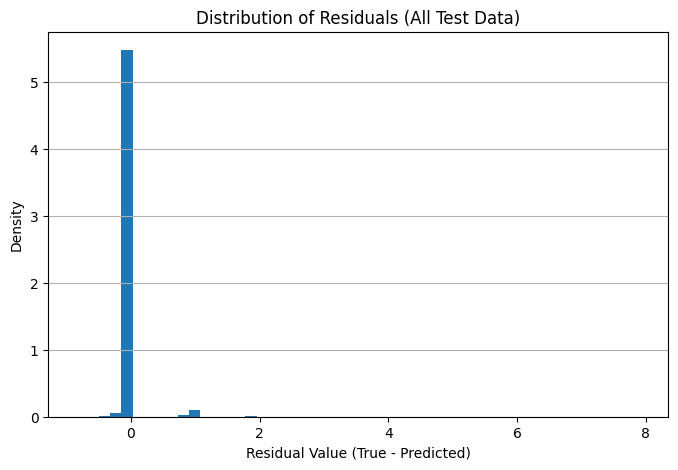

Interpretation: Ideally, residuals should be centered around zero with a roughly normal distribution.


In [ ]:
# Cell 1: Calculate Residuals and Basic Stats
import numpy as np
import matplotlib.pyplot as plt

print("\\n--- Starting Residual Analysis ---")

if 'all_preds_orig_scale' in locals() and 'all_targets_orig_scale' in locals() and len(all_preds_orig_scale) > 0:
    # Calculate Residuals (True - Predicted)
    residuals = all_targets_orig_scale - all_preds_orig_scale
    # Shape: (num_test_days, 1, H, W)

    print(f"Calculated residuals. Shape: {residuals.shape}")
    print(f"Residual Mean: {np.mean(residuals):.4f}")
    print(f"Residual Std Dev: {np.std(residuals):.4f}")
    print(f"Residual Min: {np.min(residuals):.4f}")
    print(f"Residual Max: {np.max(residuals):.4f}")

    # Visualize Residual Distribution (across all cells and days)
    plt.figure(figsize=(8, 5))
    plt.hist(residuals.flatten(), bins=50, density=True)
    plt.title('Distribution of Residuals (All Test Data)')
    plt.xlabel('Residual Value (True - Predicted)')
    plt.ylabel('Density')
    plt.grid(True, axis='y')
    plt.show()
    print("Interpretation: Ideally, residuals should be centered around zero with a roughly normal distribution.")
    residuals_available = True
else:
    print("\\nSkipping Residual Analysis: Predictions or targets not available.")
    residuals_available = False

## Temporal Analysis

\n--- Temporal Error Analysis (h(t)) ---


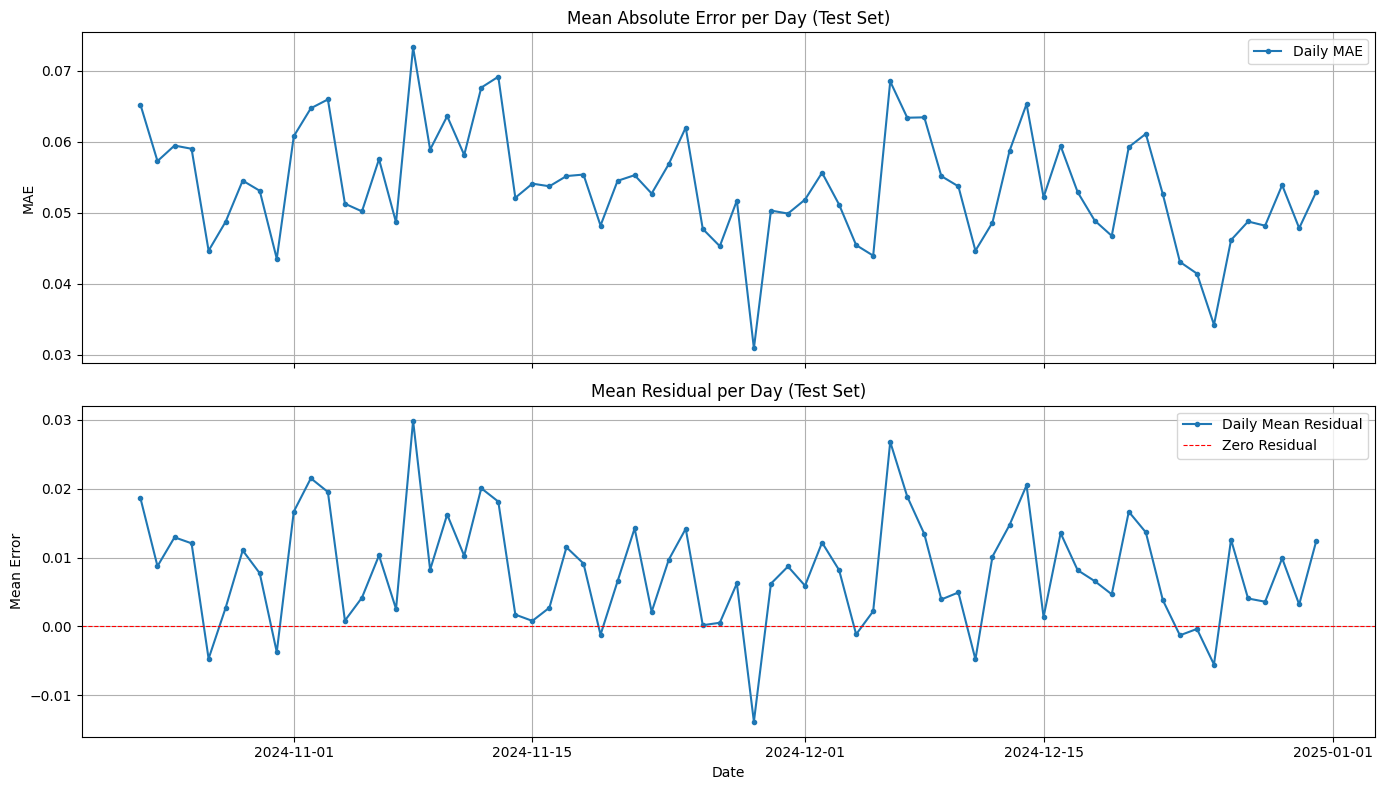

Interpretation: Look for trends, seasonality (e.g., weekly spikes), or specific dates with high errors in the MAE plot.
The Mean Residual plot shows if the model tends to over/under-predict on average on certain days.


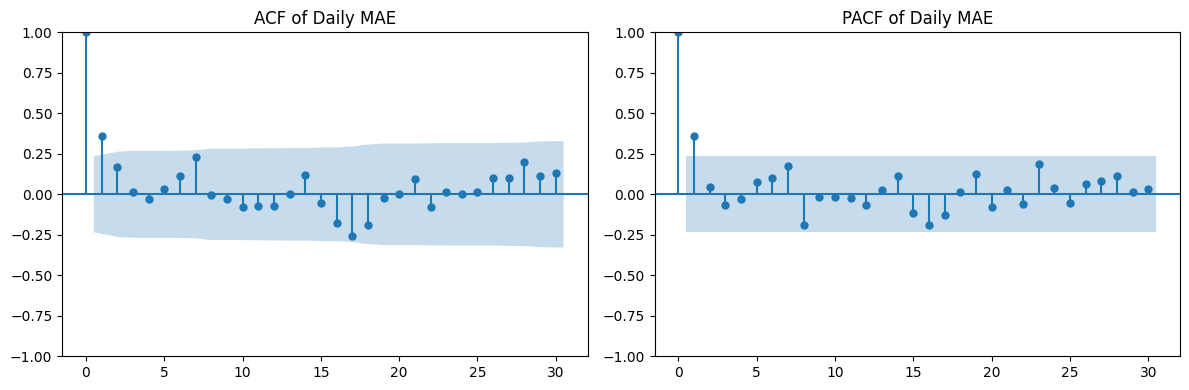

Interpretation: Spikes outside the blue confidence band in ACF/PACF suggest significant autocorrelation.
Significant spikes (esp. at lags 7, 14, etc.) indicate that the *magnitude* of error has temporal patterns (e.g., weekly) that the model isn't fully capturing. This relates to h(t).
\nLjung-Box Test for Autocorrelation in Daily MAE:
      lb_stat  lb_pvalue
7   17.090205   0.016824
14  19.880642   0.133950
Interpretation: Small lb_pvalue (e.g., < 0.05) suggests significant autocorrelation exists in the error magnitude.


In [ ]:
# Cell 2: Temporal Error Analysis
if residuals_available and len(residuals) > 1: # Need more than 1 day for time series
    print("\\n--- Temporal Error Analysis (h(t)) ---")
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.stats.diagnostic import acorr_ljungbox

    # Aggregate residuals per day (e.g., Mean Absolute Error per day)
    # Sum of absolute residuals also good, MAE normalizes for grid size
    daily_mae = np.mean(np.abs(residuals), axis=(1, 2, 3))
    daily_mean_residual = np.mean(residuals, axis=(1, 2, 3)) # Check for temporal bias

    # Plot aggregated residuals over time
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(T_test, daily_mae, label='Daily MAE', marker='.', linestyle='-')
    axes[0].set_title('Mean Absolute Error per Day (Test Set)')
    axes[0].set_ylabel('MAE')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(T_test, daily_mean_residual, label='Daily Mean Residual', marker='.', linestyle='-')
    axes[1].axhline(0, color='r', linestyle='--', linewidth=0.8, label='Zero Residual')
    axes[1].set_title('Mean Residual per Day (Test Set)')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Mean Error')
    axes[1].grid(True)
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    print("Interpretation: Look for trends, seasonality (e.g., weekly spikes), or specific dates with high errors in the MAE plot.")
    print("The Mean Residual plot shows if the model tends to over/under-predict on average on certain days.")


    # Plot ACF and PACF of Daily MAE (to check for temporal autocorrelation in error magnitude)
    if len(daily_mae) > 30: # Need enough lags for meaningful plots
        try:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            plot_acf(daily_mae, ax=axes[0], lags=min(30, len(daily_mae)//2 - 1))
            plot_pacf(daily_mae, ax=axes[1], lags=min(30, len(daily_mae)//2 - 1), method='ywm')
            axes[0].set_title('ACF of Daily MAE')
            axes[1].set_title('PACF of Daily MAE')
            plt.tight_layout()
            plt.show()
            print("Interpretation: Spikes outside the blue confidence band in ACF/PACF suggest significant autocorrelation.")
            print("Significant spikes (esp. at lags 7, 14, etc.) indicate that the *magnitude* of error has temporal patterns (e.g., weekly) that the model isn't fully capturing. This relates to h(t).")

            # Ljung-Box test (statistical test for autocorrelation)
            ljung_box_result = acorr_ljungbox(daily_mae, lags=[7, 14], return_df=True)
            print("\\nLjung-Box Test for Autocorrelation in Daily MAE:")
            print(ljung_box_result)
            print("Interpretation: Small lb_pvalue (e.g., < 0.05) suggests significant autocorrelation exists in the error magnitude.")

        except Exception as e:
            print(f"Could not generate ACF/PACF plots or Ljung-Box test: {e}")
    else:
        print("Skipping ACF/PACF/Ljung-Box: Not enough test days for analysis.")

else:
    print("\\nSkipping Temporal Error Analysis: Residuals not available or insufficient test days.")

## Spatial residual analysis

\n--- Spatial Error Analysis (g(s)) ---


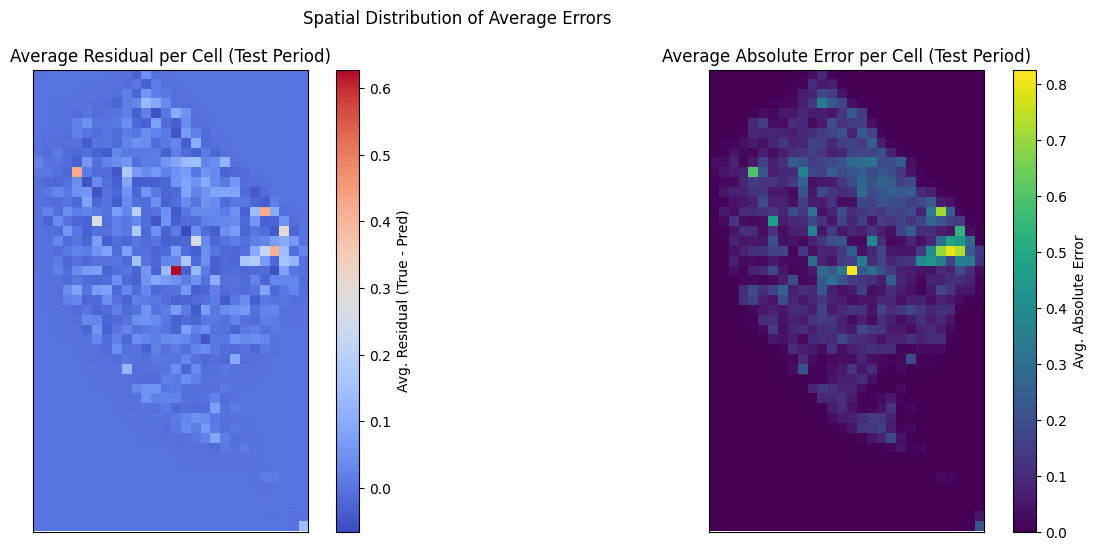

Interpretation: The Average Residual map shows areas where the model *consistently* over-predicts (blue) or under-predicts (red). This represents the spatial bias g(s).
The Average Absolute Error map shows areas where the model is *consistently* inaccurate, regardless of direction.
\nGlobal Moran's I for Average Residual Map:
  Moran's I statistic: 0.1130
  P-value (pseudo):   0.0010
  Z-score (pseudo):   8.3759
Interpretation of Moran's I for Average Residuals:
  - Positive significant I: Clustering of similar *average* errors (areas of consistent over-prediction are near each other, areas of under-prediction are near each other).
  - Negative significant I: Dispersion/Checkerboard pattern of *average* errors.
  - Non-significant I: Average errors are spatially random.
  This tests the spatial structure of the consistent spatial bias g(s).


In [ ]:
# Cell 3: Spatial Error Analysis
if residuals_available and GRID_H > 1 and GRID_W > 1: # Need spatial dimensions
    print("\\n--- Spatial Error Analysis (g(s)) ---")
    import libpysal.weights
    import esda
    import splot.esda

    # Aggregate residuals over time for each cell (Average Residual)
    mean_residual_map = np.mean(residuals, axis=0)[0, :, :] # Average over days, remove time/channel dim
    # Also calculate average absolute error per cell
    mean_abs_error_map = np.mean(np.abs(residuals), axis=0)[0, :, :]

    # Plot the maps
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    cmap_bias = 'coolwarm' # Good for showing positive/negative bias
    cmap_mag = 'viridis'  # Good for showing magnitude

    im0 = axes[0].imshow(mean_residual_map, cmap=cmap_bias, interpolation='nearest')
    axes[0].set_title('Average Residual per Cell (Test Period)')
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    fig.colorbar(im0, ax=axes[0], label='Avg. Residual (True - Pred)')

    im1 = axes[1].imshow(mean_abs_error_map, cmap=cmap_mag, interpolation='nearest')
    axes[1].set_title('Average Absolute Error per Cell (Test Period)')
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    fig.colorbar(im1, ax=axes[1], label='Avg. Absolute Error')

    plt.suptitle("Spatial Distribution of Average Errors")
    plt.show()
    print("Interpretation: The Average Residual map shows areas where the model *consistently* over-predicts (blue) or under-predicts (red). This represents the spatial bias g(s).")
    print("The Average Absolute Error map shows areas where the model is *consistently* inaccurate, regardless of direction.")


    # Calculate Global Moran's I for the Mean Residual Map (Spatial Autocorrelation)
    try:
        # Create spatial weights matrix (Queen contiguity)
        # Assumes a regular grid structure
        w = libpysal.weights.lat2W(GRID_H, GRID_W, rook=False) # rook=False means Queen
        w.transform = 'R' # Row-standardize weights

        # Calculate Moran's I statistic for the average residual map
        moran_mean_res = esda.moran.Moran(mean_residual_map.flatten(), w)
        print(f"\\nGlobal Moran's I for Average Residual Map:")
        print(f"  Moran's I statistic: {moran_mean_res.I:.4f}")
        print(f"  P-value (pseudo):   {moran_mean_res.p_sim:.4f}")
        print(f"  Z-score (pseudo):   {moran_mean_res.z_sim:.4f}")
        print("Interpretation of Moran's I for Average Residuals:")
        print("  - Positive significant I: Clustering of similar *average* errors (areas of consistent over-prediction are near each other, areas of under-prediction are near each other).")
        print("  - Negative significant I: Dispersion/Checkerboard pattern of *average* errors.")
        print("  - Non-significant I: Average errors are spatially random.")
        print("  This tests the spatial structure of the consistent spatial bias g(s).")

        # Optional: Plot Local Moran's I map (identifies clusters/outliers in average error)
        # moran_loc = esda.moran.Moran_Local(mean_residual_map.flatten(), w)
        # fig, ax = splot.esda.plot_local_moran(moran_loc, mean_residual_map.flatten(), figsize=(8,8))
        # ax.set_title("Local Moran's I for Average Residuals")
        # plt.show()

    except Exception as e:
        print(f"\\nCould not perform spatial autocorrelation analysis: {e}")
        print("Ensure libpysal, esda, and splot are installed and GRID_H/GRID_W are correct.")

else:
    print("\\nSkipping Spatial Error Analysis: Residuals not available or grid dimensions unsuitable.")

### Extract location information from high error areas

In [ ]:
# Cell 5: Investigate High-Error Grid Cell(s)
import numpy as np
import pandas as pd

print("\\n--- Investigating High-Error Grid Cell(s) ---")

# --- Configuration ---
# Set how many top error cells you want to investigate
top_n_cells = 1

# --- Check if necessary data is available ---
required_vars = ['mean_abs_error_map', 'lat_bins', 'lon_bins', 'theft_data', 'T_test', 'GRID_H', 'GRID_W']
missing_vars = None #[var for var in required_vars if var not in locals()]

if missing_vars:
    print(f"Skipping investigation: Missing required data: {', '.join(missing_vars)}")
elif not isinstance(theft_data, pd.DataFrame) or theft_data.empty:
     print("Skipping investigation: 'theft_data' DataFrame is missing or empty.")
elif len(T_test) == 0:
     print("Skipping investigation: 'T_test' (list of test dates) is empty.")
elif mean_abs_error_map.size == 0:
     print("Skipping investigation: 'mean_abs_error_map' is empty.")
else:
    # Flatten the error map to find top errors easily
    flat_error_map = mean_abs_error_map.flatten()

    # Get the indices of the cells with the highest errors
    # Argsort sorts in ascending order, so we take the last 'top_n_cells'
    top_indices_flat = np.argsort(flat_error_map)[-top_n_cells:]

    # Convert flat indices back to 2D grid coordinates
    top_indices_2d = np.unravel_index(top_indices_flat, (GRID_H, GRID_W))

    # Get the start and end dates of the test period
    test_start_date = min(T_test).date()
    test_end_date = max(T_test).date()
    print(f"Analyzing test period: {test_start_date} to {test_end_date}")

    # Iterate through the top N cells found
    # Note: unravel_index returns a tuple of arrays (one for row indices, one for col indices)
    for i in range(top_n_cells):
        # Get the grid coordinates (row h, column w) for the i-th highest error cell
        # We iterate backwards through top_indices_flat to get highest error first
        cell_h_idx = top_indices_2d[0][::-1][i] # Row index
        cell_w_idx = top_indices_2d[1][::-1][i] # Column index
        cell_error_value = mean_abs_error_map[cell_h_idx, cell_w_idx]

        print(f"\n--- Cell #{i+1} (Highest Error) ---")
        print(f"  Grid Coordinates (H, W): ({cell_h_idx}, {cell_w_idx})")
        print(f"  Average Absolute Error: {cell_error_value:.4f}")

        # Determine the Lat/Lon boundaries for this cell
        # Ensure indices are within bounds of the bins array
        if cell_h_idx < len(lat_bins) - 1 and cell_w_idx < len(lon_bins) - 1:
            lat_min_boundary = lat_bins[cell_h_idx]
            lat_max_boundary = lat_bins[cell_h_idx + 1]
            lon_min_boundary = lon_bins[cell_w_idx]
            lon_max_boundary = lon_bins[cell_w_idx + 1]

            print(f"  Latitude Range:  {lat_min_boundary:.6f} to {lat_max_boundary:.6f}")
            print(f"  Longitude Range: {lon_min_boundary:.6f} to {lon_max_boundary:.6f}")

            # Filter the original theft_data for incidents within this cell and during the test period
            try:
                # Make sure IncidentDate is datetime type if not already
                if not pd.api.types.is_datetime64_any_dtype(theft_data['IncidentDate']):
                     theft_data['IncidentDate'] = pd.to_datetime(theft_data['IncidentDate'])

                # Filter spatially and temporally
                cell_crimes = theft_data[
                    (theft_data['Latitude'] >= lat_min_boundary) &
                    (theft_data['Latitude'] < lat_max_boundary) & # Use < for max boundary typically
                    (theft_data['Longitude'] >= lon_min_boundary) &
                    (theft_data['Longitude'] < lon_max_boundary) &
                    (theft_data['IncidentDate'].dt.date >= test_start_date) &
                    (theft_data['IncidentDate'].dt.date <= test_end_date)
                ]

                print(f"\n  Crimes in this cell during test period ({test_start_date} to {test_end_date}):")
                print(f"  Total incidents found: {cell_crimes.shape[0]}")

                if not cell_crimes.empty:
                    print("  Sample Incidents:")
                    print(cell_crimes[['IncidentDate', 'Latitude', 'Longitude', 'Offense', 'IncidentLocation']].head())

                    # Optional: Add more analysis like value counts of locations or offense types
                    if 'IncidentLocation' in cell_crimes.columns:
                         print("\n  Most frequent locations in this cell (Test Period):")
                         print(cell_crimes['IncidentLocation'].value_counts().head())
                    if 'Offense' in cell_crimes.columns:
                         print("\n  Most frequent offenses in this cell (Test Period):")
                         print(cell_crimes['Offense'].value_counts().head())

                else:
                    print("  No specific crime incidents found in the original data for this exact cell and test date range.")
                    print("  This could happen due to boundary precision or if the error source is complex.")

            except Exception as e:
                 print(f"  Error filtering crime data: {e}")

        else:
            print("  Error: Cell indices seem out of bounds for lat/lon bins.")

\n--- Investigating High-Error Grid Cell(s) ---
Analyzing test period: 2024-10-23 to 2024-12-31

--- Cell #1 (Highest Error) ---
  Grid Coordinates (H, W): (20, 14)
  Average Absolute Error: 0.8253
  Latitude Range:  38.637847 to 38.642847
  Longitude Range: -90.249490 to -90.244490

  Crimes in this cell during test period (2024-10-23 to 2024-12-31):
  Total incidents found: 58
  Sample Incidents:
       IncidentDate   Latitude  Longitude  \
209565   2024-10-24  38.639853 -90.247185   
210105   2024-10-28  38.640178 -90.249214   
210199   2024-10-29  38.640228 -90.249320   
210246   2024-10-29  38.640153 -90.245380   
210657   2024-11-02  38.639465 -90.245761   

                                                  Offense   IncidentLocation  
209565                                           STEALING  4140 LINDELL BLVD  
210105  STEALING UNDER $150 (PETTY LARCENY - SHOPLIFTING)  4218 LINDELL BLVD  
210199                             STEALING/LARCENY/THEFT  4218 LINDELL BLVD  
210246     

## Spatiotemporal Analysis

\n--- Spatiotemporal Interaction Analysis (f(s, t)) ---
Analyzing how spatial error patterns change over time.


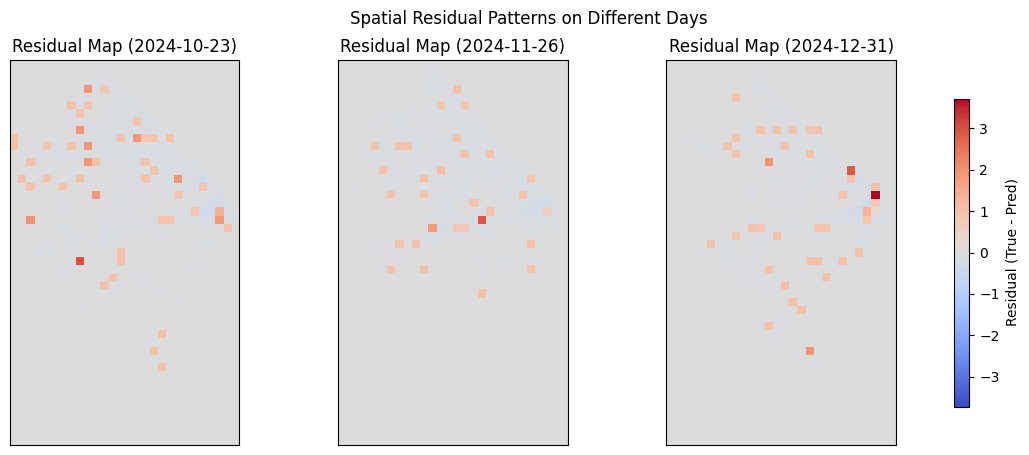

Interpretation: Compare these daily residual maps to each other and to the 'Average Residual Map' from Cell 3.
  - If daily maps look very similar to the average map, f(s, t) might be small.
  - If daily maps show very different spatial patterns on different days (beyond what's expected from the daily MAE changes in Cell 2), it suggests strong spatiotemporal interaction f(s, t).
  - Look for error hotspots that appear/disappear or move over time.
\nCalculating Moran's I for individual days:
  Moran's I (2024-10-23): -0.0087 (p=0.2900)
  Moran's I (2024-11-26): -0.0288 (p=0.0010)
  Moran's I (2024-12-31): 0.0154 (p=0.1030)
Interpretation: If Moran's I varies significantly across days, the spatial structure of the error changes over time, indicating f(s, t).


In [ ]:
# Cell 4: Spatiotemporal Interaction Analysis (Qualitative)
if residuals_available and GRID_H > 1 and GRID_W > 1: # Need spatial dimensions
    print("\\n--- Spatiotemporal Interaction Analysis (f(s, t)) ---")
    print("Analyzing how spatial error patterns change over time.")

    # Visualize residual maps for a few different days
    num_days_to_plot = 3
    if len(residuals) >= num_days_to_plot:
        indices_to_plot = np.linspace(0, len(residuals) - 1, num_days_to_plot, dtype=int)

        fig, axes = plt.subplots(1, num_days_to_plot, figsize=(5 * num_days_to_plot, 5))
        if num_days_to_plot == 1: axes = [axes] # Ensure axes is iterable

        max_abs_val = np.max(np.abs(residuals[indices_to_plot])) # Consistent scale

        for i, day_idx in enumerate(indices_to_plot):
            residual_map_day = residuals[day_idx, 0, :, :]
            date_str = T_test[day_idx].date()

            im = axes[i].imshow(residual_map_day, cmap='coolwarm', interpolation='nearest',
                                vmin=-max_abs_val, vmax=max_abs_val)
            axes[i].set_title(f'Residual Map ({date_str})')
            axes[i].set_xticks([])
            axes[i].set_yticks([])

        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='Residual (True - Pred)')
        plt.suptitle("Spatial Residual Patterns on Different Days")
        plt.show()

        print("Interpretation: Compare these daily residual maps to each other and to the 'Average Residual Map' from Cell 3.")
        print("  - If daily maps look very similar to the average map, f(s, t) might be small.")
        print("  - If daily maps show very different spatial patterns on different days (beyond what's expected from the daily MAE changes in Cell 2), it suggests strong spatiotemporal interaction f(s, t).")
        print("  - Look for error hotspots that appear/disappear or move over time.")

        # Optional: Calculate Moran's I for these specific days and compare
        print("\\nCalculating Moran's I for individual days:")
        try:
             # Reuse weights matrix 'w' from Cell 3 if available
            if 'w' in locals():
                 for i, day_idx in enumerate(indices_to_plot):
                     residual_map_day_flat = residuals[day_idx, 0, :, :].flatten()
                     moran_day = esda.moran.Moran(residual_map_day_flat, w)
                     date_str = T_test[day_idx].date()
                     print(f"  Moran's I ({date_str}): {moran_day.I:.4f} (p={moran_day.p_sim:.4f})")
                 print("Interpretation: If Moran's I varies significantly across days, the spatial structure of the error changes over time, indicating f(s, t).")
            else:
                 print("  Skipping daily Moran's I: Spatial weights 'w' not calculated.")
        except Exception as e:
            print(f"  Could not calculate daily Moran's I: {e}")

    else:
        print("Not enough test days to plot multiple residual maps.")

else:
    print("\\nSkipping Spatiotemporal Interaction Analysis: Residuals not available or grid dimensions unsuitable.")

# Next Steps

*   Experiment with grid resolution (`bin_size_deg`).
*   Tune hyperparameters (hidden channels, layers, learning rate, SE reduction).
*   Implement a more robust Mean Hit Rate calculation based on specific hotspot definitions.
*   Consider adding external features if available (weather, demographics per grid cell).
*   Integrate the trained PyTorch model into the web application for visualization and interaction.
